# Analysis of the Gun Violence Dataset

# Predictive Modeling of Incident Severity

Authors: Kacper Neumann, Stanisław Apanasiewicz, Jan Matusiak

----

In this notebook, we build models to predict the severity of gun violence incidents.

We frame the problem in the following ways:
1. **Has Casualties vs No Casualties (Classification):** Binary prediciton of `n_killed + n_injured > 0`.

In [1951]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

np.random.seed(42)

## 1. Loading Data

In [1952]:
df = pd.read_parquet("../data/incidents.parquet")

In [1953]:
# Merge race data
df_race = pd.read_csv("../data/state_race_2015.csv")
race_cols = [
    "pct_white",
    "pct_black",
    "pct_hispanic",
    "pct_asian",
    "pct_native",
    "pct_mixed",
]
df = df.merge(df_race, on="state", how="left")
df[["state"] + race_cols].head()

,state,pct_white,pct_black,pct_hispanic,pct_asian,pct_native,pct_mixed
0,Pennsylvania,76.0,10.0,8.0,4.0,0.0,2.0
1,California,36.0,5.0,40.0,15.0,0.0,3.0
2,Ohio,79.0,12.0,4.0,2.0,0.0,3.0
3,Colorado,68.0,4.0,22.0,3.0,1.0,3.0
4,North Carolina,63.0,21.0,10.0,3.0,1.0,3.0


In [1954]:
df[race_cols].isna().sum()

pct_white       0
pct_black       0
pct_hispanic    0
pct_asian       0
pct_native      0
pct_mixed       0
dtype: int64

In [1955]:
# Merge unemployment data
df_unemployment = pd.read_csv("../data/state_unemployment_2015.csv")
df = df.merge(df_unemployment, on="state", how="left")
df[["state", "unemployment"]].head()

,state,unemployment
0,Pennsylvania,5.2
1,California,6.2
2,Ohio,4.9
3,Colorado,3.9
4,North Carolina,5.9


In [1956]:
df["unemployment"].isna().sum()

np.int64(0)

## 2. Feature Selection & Preparation

In [1957]:
# Date features
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

In [1958]:
base_features = [
    "month",
    "day_of_week",
    "n_guns_involved",
    "latitude",
    "longitude",
]

features = base_features + ["unemployment"] + race_cols

X_raw = df[features].copy()
X = pd.get_dummies(X_raw, columns=["month", "day_of_week"], drop_first=True)

## 3. Modeling

### 3.1 Casualties vs. No Casualties (Binary Classification)

We can frame this as predicting whether an incident will have **any casualties at all** (Killed + Injured > 0) versus **no casualties** (property damage, shots fired, but no one hit). This is a more balanced binary problem compare to severity tier classification which is difficult due to class imbalance.

In [1959]:
# Binary target: 1 if any casualties, 0 otherwise
df["target_has_casualties"] = (df["n_killed"] + df["n_injured"] > 0).astype(int)
df["target_has_casualties"].value_counts(normalize=True)

target_has_casualties
1    0.594091
0    0.405909
Name: proportion, dtype: float64

In [1960]:
y_bin = df["target_has_casualties"]
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin, random_state=42
)

### Random Forest

In [1961]:
from sklearn.ensemble import RandomForestClassifier

rf_bin = RandomForestClassifier(
    n_jobs=-1, random_state=42, oob_score=True, max_depth=30, min_samples_leaf=10
)
rf_bin.fit(X_train_bin, y_train_bin)
print(f"Random Forest OOB Score (Accuracy): {rf_bin.oob_score_:.4f}")

Random Forest OOB Score (Accuracy): 0.6916


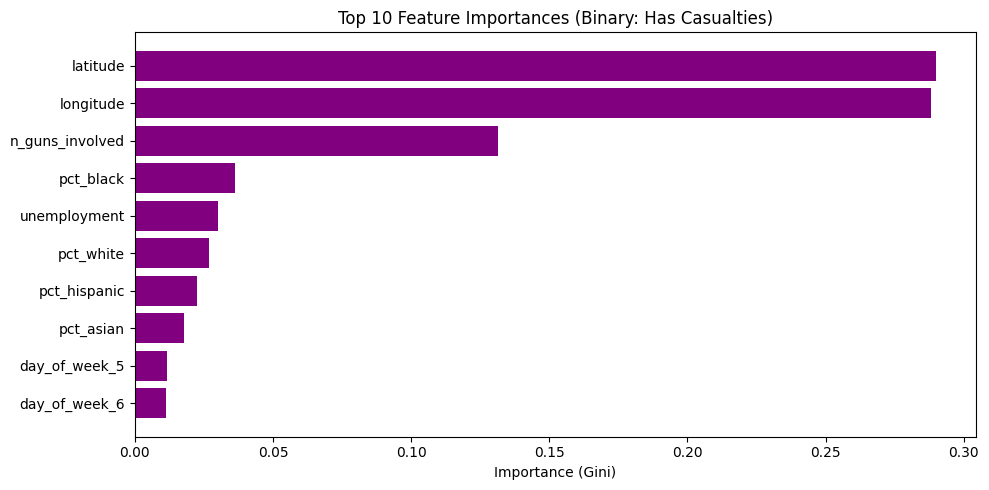

In [1962]:
importances_bin = rf_bin.feature_importances_
top_idx_bin = np.argsort(importances_bin)[-10:]

plt.figure(figsize=(10, 5))
plt.barh(X.columns[top_idx_bin], importances_bin[top_idx_bin], color="purple")
plt.title("Top 10 Feature Importances (Binary: Has Casualties)")
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

In [1963]:
y_pred_bin = rf_bin.predict(X_test_bin)
print("Classification Report (Random Forest):")
print(
    classification_report(
        y_test_bin, y_pred_bin, target_names=["No Casualties (0)", "Has Casualties (1)"]
    )
)

Classification Report (Random Forest):
                    precision    recall  f1-score   support

 No Casualties (0)       0.67      0.48      0.56     19458
Has Casualties (1)       0.70      0.83      0.76     28478

          accuracy                           0.69     47936
         macro avg       0.68      0.66      0.66     47936
      weighted avg       0.69      0.69      0.68     47936



The model is not particularly good. The problem of missing values is likely a part of it. Also, we do not use any participant-related features as these are more descriptive of the events and would lead to losing predictive power.

We can see that the model heavily relies on `latitude` and `longitude`, then on `n_guns_involved` which unfortunately contains a lot of missing values.

We can also incorporate some of the `incident_characteristics`. We will use some of the top ones discovered in [02_eda.ipynb](02_eda.ipynb) while ignoring those that leak information about `n_killed` or `n_injured`.

In [1964]:
# Contextual characteristics to extract
contextual_characteristics = [
    "Drug involvement",
    "Drive-by",
    "Institution/Group/Business",
    "Domestic Violence",
    "Home Invasion",
    "Gang involvement",
    "Bar/club incident",
]

df["incident_characteristics"] = df["incident_characteristics"].fillna("")
char_features = []

for char in contextual_characteristics:
    # Create simple binary flags
    feature_name = (
        f"char_{char.split(' ')[0].lower().replace('/', '_').replace('-', '_')}"
    )
    df[feature_name] = (
        df["incident_characteristics"].str.contains(char, regex=False).astype(int)
    )
    char_features.append(feature_name)

print("Created characteristic features:", char_features)

Created characteristic features: ['char_drug', 'char_drive_by', 'char_institution_group_business', 'char_domestic', 'char_home', 'char_gang', 'char_bar_club']


In [1965]:
X_chars = pd.get_dummies(
    df[features + char_features], columns=["month", "day_of_week"], drop_first=True
)
X_chars.head()

,n_guns_involved,latitude,longitude,unemployment,pct_white,pct_black,pct_hispanic,pct_asian,pct_native,pct_mixed,...,month_9,month_10,month_11,month_12,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,NaN,40.3467,-79.8559,5.2,76.0,10.0,8.0,4.0,0.0,2.0,...,False,False,False,False,True,False,False,False,False,False
1,NaN,33.9090,-118.3330,6.2,36.0,5.0,40.0,15.0,0.0,3.0,...,False,False,False,False,True,False,False,False,False,False
2,2.0,41.4455,-82.1377,4.9,79.0,12.0,4.0,2.0,0.0,3.0,...,False,False,False,False,True,False,False,False,False,False
3,NaN,39.6518,-104.8020,3.9,68.0,4.0,22.0,3.0,1.0,3.0,...,False,False,False,False,False,False,False,False,True,False
4,2.0,36.1140,-79.9569,5.9,63.0,21.0,10.0,3.0,1.0,3.0,...,False,False,False,False,False,False,False,False,False,False


In [1966]:
X_train_bin_chars, X_test_bin_chars, y_train_bin_chars, y_test_bin_chars = (
    train_test_split(X_chars, y_bin, test_size=0.2, stratify=y_bin, random_state=42)
)

In [1967]:
rf_bin_chars = RandomForestClassifier(
    n_jobs=-1, random_state=42, oob_score=True, max_depth=30, min_samples_leaf=5
)
rf_bin_chars.fit(X_train_bin_chars, y_train_bin_chars)
print(f"Random Forest OOB Score (Accuracy): {rf_bin_chars.oob_score_:.4f}")

Random Forest OOB Score (Accuracy): 0.7153


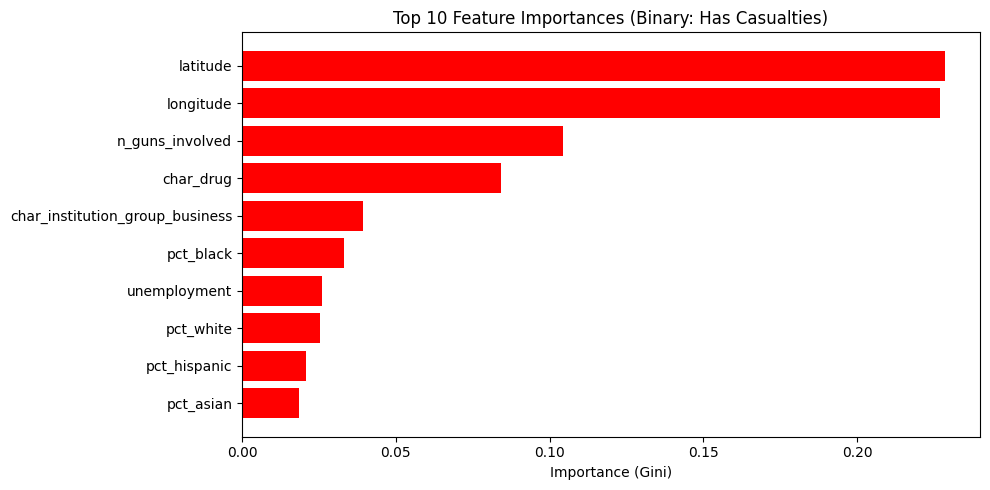

In [1968]:
importances_bin_chars = rf_bin_chars.feature_importances_
top_idx_bin_chars = np.argsort(importances_bin_chars)[-10:]

plt.figure(figsize=(10, 5))
plt.barh(
    X_chars.columns[top_idx_bin_chars],
    importances_bin_chars[top_idx_bin_chars],
    color="red",
)
plt.title("Top 10 Feature Importances (Binary: Has Casualties)")
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

In [1969]:
y_pred_bin_chars = rf_bin_chars.predict(X_test_bin_chars)
print("Classification Report (Random Forest):")
print(
    classification_report(
        y_test_bin_chars,
        y_pred_bin_chars,
        target_names=["No Casualties (0)", "Has Casualties (1)"],
    )
)

Classification Report (Random Forest):
                    precision    recall  f1-score   support

 No Casualties (0)       0.71      0.51      0.59     19458
Has Casualties (1)       0.72      0.86      0.78     28478

          accuracy                           0.72     47936
         macro avg       0.71      0.68      0.69     47936
      weighted avg       0.71      0.72      0.70     47936



We can see that these new features definitely explain some of the examples, but the improvement is not very significant.